In [2]:
import sys
import os
import pandas as pd
import numpy as np
import csv
import pip
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import statsmodels.api as sm
import linearmodels as lm
from linearmodels import PanelOLS, RandomEffects
from scipy import stats
from linearmodels import RandomEffects
import statsmodels.api as sm
from linearmodels.panel import compare

In [3]:
final_df = pd.read_csv("prepared_data_for_regression.csv")
print(final_df.head(5))

      country  year  incidence  mortality       log_gdp       bmi    pop_65  \
0        fiji  2000  39.310026  33.722967   9426.113813  0.303726  3.437768   
1    cambodia  2000  11.807551  10.664151   1922.031791  0.100004  2.816518   
2    kiribati  2000  13.866566  12.601468   2481.415243  0.307055  3.413156   
3  kazakhstan  2000  35.284421  18.655098  12935.864368  0.291659  6.693366   
4     jamaica  2000  50.404926  25.599975   9518.231763  0.240683  6.060642   

   urban_pop  fertility  labor_rate  internet  health_exp  smoking  hosp_beds  \
0     47.908      2.992      37.841  1.496850    3.424412     15.9       2.05   
1     18.586      3.794      77.834  0.047023    6.482484     23.5       0.60   
2     42.958      4.071         NaN  1.785230    7.773798     53.9       1.32   
3     56.098      1.898      65.381  0.668594    4.160324     12.0       6.90   
4     51.814      2.345      58.147  3.115780    5.644625      8.8       1.70   

        MIR  
0  0.857872  
1  0.90316

In [4]:
initial_countries=final_df['country'].nunique()
print(initial_countries)

166


In [5]:
initial_years=final_df['year'].nunique()
print(initial_years)

24


# OECD  Countries :

In [6]:
oecd_countries = ['austria', 'australia', 'belgium', 'canada', 'chile', 
                  'colombia', 'czechia', 'denmark', 'estonia', 'finland', 
                  'france', 'germany', 'greece', 'hungary', 'iceland', 'ireland', 
                  'israel', 'italy', 'japan', 'korea', 'latvia', 'lithuania', 'luxembourg', 
                  'mexico', 'netherlands', 'new zealand', 'norway', 'poland', 'portugal', 'slovakia', 
                  'slovenia', 'spain', 'sweden', 'switzerland', 'turkiye', 'united kingdom', 'united states', 'costa rica']
print(len(oecd_countries))

38


# Create Dummy Variables:

In [7]:
final_df['is_oecd'] = final_df['country'].isin(oecd_countries).astype(int)

# create interaction :

In [8]:
final_df['bmi_x_oecd'] = final_df['bmi']* final_df['is_oecd']
print(final_df['is_oecd'].value_counts())

is_oecd
0    2860
1     808
Name: count, dtype: int64


# Heat_Map:

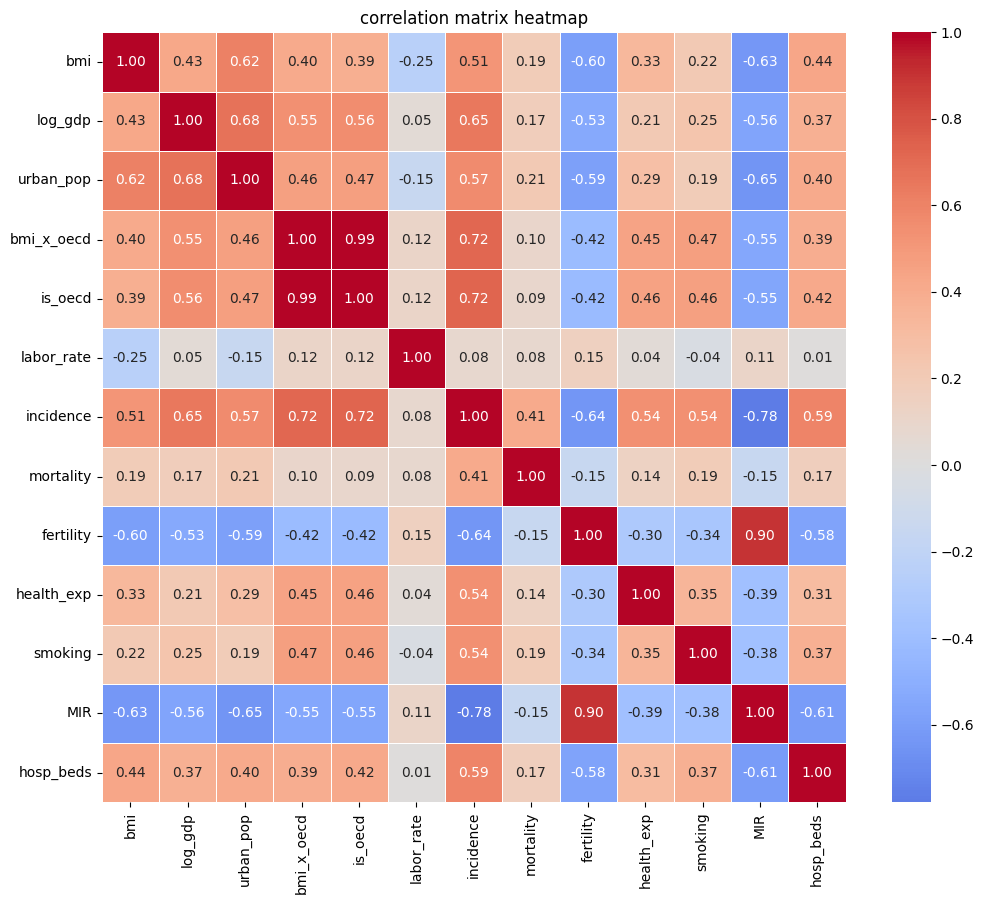

In [9]:
columns_for_heatmap=['bmi', 'log_gdp', 'urban_pop', 'bmi_x_oecd', 'is_oecd', 'labor_rate'
                      ,'incidence', 'mortality', 'fertility','health_exp','smoking','MIR','hosp_beds']
correlation_matrix = final_df[columns_for_heatmap].corr()
plt.figure(figsize= (12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('correlation matrix heatmap')
plt.show()

# Dummy Variables: 

In [10]:
oecd_comparison= final_df.groupby('is_oecd').incidence.mean()
print(final_df['is_oecd'].value_counts())

is_oecd
0    2860
1     808
Name: count, dtype: int64


1. Aging Society Dummy: Based on WHO standards, societies with >10% population over 65 are considered "ageing" or "aged". This captures potential non-linear increases in cancer incidence due to population structure.

In [11]:
final_df['dm_high_aging_society'] = (final_df['pop_65'] > 10).astype(int)
print(final_df['dm_high_aging_society'].value_counts())

dm_high_aging_society
0    2457
1    1211
Name: count, dtype: int64


2. High Life Expectancy Dummy threshold of 75 years represents advanced healthcare systems and higher probability of disease detection.

In [12]:
print(final_df[['year', 'country', 'is_oecd', 'dm_high_aging_society']].head(100))

    year       country  is_oecd  dm_high_aging_society
0   2000          fiji        0                      0
1   2000      cambodia        0                      0
2   2000      kiribati        0                      0
3   2000    kazakhstan        0                      0
4   2000       jamaica        0                      0
..   ...           ...      ...                    ...
95  2000       denmark        1                      1
96  2001          oman        0                      0
97  2000       lebanon        0                      0
98  2000       namibia        0                      0
99  2000  saudi arabia        0                      0

[100 rows x 4 columns]


# interaction of is_oecd variable and gdp

In [13]:
final_df['log_gdp_is_oecd']= final_df['log_gdp']*final_df['is_oecd']
print(final_df['log_gdp_is_oecd'].head(5))

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: log_gdp_is_oecd, dtype: float64


In [14]:
final_df['is_oecd'] = 0
final_df.loc[final_df['country'].isin(oecd_countries), 'is_oecd'] = 1

# interaction of is_oecd variable and gdp
final_df['log_gdp_is_oecd'] = final_df['log_gdp'] * final_df['is_oecd']
# Filling NaNs in Interaction Term: Since 'NaN * 0 = NaN' in Python, rows where is_oecd is 0 but log_gdp is missing(NAN) 
# would incorrectly stay as NaN (and be counted in the results), then filled these with 0 to ensure only real OECD countries with data are counted.
final_df['log_gdp_is_oecd'] = final_df['log_gdp_is_oecd'].fillna(0)

# counting contries :
oecd_count = final_df[final_df['is_oecd'] == 1]['country'].nunique()
interaction_countries = final_df[final_df['log_gdp_is_oecd'] != 0]['country'].nunique()

In [15]:
#print(final_df[['year', 'country', 'gdp_is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))
print(final_df[['country','log_gdp','is_oecd','log_gdp_is_oecd','dm_high_aging_society']].sample(15).round(2))

                     country    log_gdp  is_oecd  log_gdp_is_oecd  \
2701               lithuania   43062.32        1         43062.32   
2756            sierra leone    2855.23        0             0.00   
3199                  france   52517.34        1         52517.34   
2990              mozambique    1512.60        0             0.00   
63               new zealand   36885.64        1         36885.64   
2625                 grenada   13394.52        0             0.00   
1364                   samoa    6017.48        0             0.00   
1335                    peru   11204.38        0             0.00   
905                   belize   12900.11        0             0.00   
2346                paraguay   14826.66        0             0.00   
2530                 namibia   11408.73        0             0.00   
3570               singapore  132617.35        0             0.00   
1599  bosnia and herzegovina   12484.22        0             0.00   
754                  burundi     9

# delete percentage of rows with missing value(NA):

In [16]:
missing_report = ((final_df.isnull().sum() / len(final_df)) * 100).round(2)
print(missing_report[missing_report > 0]) 

log_gdp        1.09
labor_rate     2.48
internet       1.64
smoking       10.88
hosp_beds      0.63
dtype: float64


In [17]:
clean_df= final_df.dropna(subset=['mortality', 'log_gdp', 'pop_65', 'urban_pop', 'fertility', 'labor_rate', 'log_gdp_is_oecd', 'internet', 'health_exp', 'smoking'])
print(f" Missing values after deleting NA in clean_df: {clean_df.isnull().sum()}")

 Missing values after deleting NA in clean_df: country                   0
year                      0
incidence                 0
mortality                 0
log_gdp                   0
bmi                       0
pop_65                    0
urban_pop                 0
fertility                 0
labor_rate                0
internet                  0
health_exp                0
smoking                   0
hosp_beds                23
MIR                       0
is_oecd                   0
bmi_x_oecd                0
dm_high_aging_society     0
log_gdp_is_oecd           0
dtype: int64


# Building stepwise regression

# Model 1: Adding gdp and urbanisation Variables:

In [18]:
df_step= clean_df.set_index(['country', 'year'])
exog_1_fe= sm.add_constant(df_step[['log_gdp', 'urban_pop']])
model_1_fe=PanelOLS(df_step['mortality'],exog_1_fe, entity_effects=True, time_effects=True).fit(cov_type='clustered',
                                                                                                 cluster_entity=True)
print(model_1_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.1591
Estimator:                   PanelOLS   R-squared (Between):             -0.8698
No. Observations:                3147   R-squared (Within):               0.1613
Date:                Mon, Apr 13 2026   R-squared (Overall):             -0.7037
Time:                        16:19:10   Log-likelihood                   -7047.0
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      282.48
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.971   Distribution:                  F(2,2985)
Min Obs:                       17.000                                           
Max Obs:                       24.000   F-statistic (robust):             16.001
                            

# Model 2: Adding Demographic Variables:

In [19]:
exog_2_fe=sm.add_constant(df_step[['log_gdp', 'urban_pop', 'log_gdp_is_oecd', 'pop_65','dm_high_aging_society','fertility']])
model_2_fe = PanelOLS(df_step['mortality'], exog_2_fe, entity_effects=True, time_effects=True).fit(cov_type='clustered',
                                                                                                   cluster_entity=True)
print(model_2_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3681
Estimator:                   PanelOLS   R-squared (Between):             -1.7033
No. Observations:                3147   R-squared (Within):               0.3613
Date:                Mon, Apr 13 2026   R-squared (Overall):             -1.3912
Time:                        16:19:10   Log-likelihood                   -6597.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      289.40
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.971   Distribution:                  F(6,2981)
Min Obs:                       17.000                                           
Max Obs:                       24.000   F-statistic (robust):             24.175
                            

# create labor_rate * is_oecd variable:

In [20]:
df_step['labor_rate * is_oecd']= df_step['labor_rate']* df_step['is_oecd']

# Model 3: Adding Lifestyle Variables:

In [21]:
exog_3_fe=sm.add_constant(df_step[['log_gdp', 'urban_pop','pop_65', 'dm_high_aging_society','fertility','bmi', 'smoking']])
model_3_fe=PanelOLS(df_step['mortality'], exog_3_fe, entity_effects=True, time_effects= True).fit(cov_type='clustered',
                                                                                                   cluster_entity= True)
print(model_3_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4275
Estimator:                   PanelOLS   R-squared (Between):             -1.4733
No. Observations:                3147   R-squared (Within):               0.3934
Date:                Mon, Apr 13 2026   R-squared (Overall):             -1.1643
Time:                        16:19:10   Log-likelihood                   -6442.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      317.84
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.971   Distribution:                  F(7,2980)
Min Obs:                       17.000                                           
Max Obs:                       24.000   F-statistic (robust):             28.204
                            

# Model 4: Adding Interaction Terms Variables:

In [22]:
exog_4_fe=sm.add_constant(df_step[['log_gdp', 'urban_pop', 'log_gdp_is_oecd', 'pop_65','dm_high_aging_society',
                                   'fertility', 'bmi','smoking','health_exp','internet','labor_rate']])
model_4_fe=PanelOLS(df_step['mortality'], exog_4_fe, entity_effects=True, time_effects= True).fit(cov_type='clustered',
                                                                                                   cluster_entity= True)
print(model_4_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4485
Estimator:                   PanelOLS   R-squared (Between):             -1.5036
No. Observations:                3147   R-squared (Within):               0.3214
Date:                Mon, Apr 13 2026   R-squared (Overall):             -1.2154
Time:                        16:19:10   Log-likelihood                   -6383.2
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      220.06
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.971   Distribution:                 F(11,2976)
Min Obs:                       17.000                                           
Max Obs:                       24.000   F-statistic (robust):             22.485
                            

# Model 5: Adding Interaction Terms Variable:

In [23]:
exog_5_fe=sm.add_constant(df_step[['log_gdp', 'urban_pop','pop_65', 'dm_high_aging_society','fertility','bmi', 'smoking', 'labor_rate', 'internet', 
                                   'log_gdp_is_oecd','labor_rate * is_oecd']])
model_5_fe=PanelOLS(df_step['mortality'], exog_5_fe, entity_effects=True, time_effects=True).fit(cov_type='clustered', cluster_entity= True)
print(model_5_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.4438
Estimator:                   PanelOLS   R-squared (Between):             -1.7407
No. Observations:                3147   R-squared (Within):               0.3232
Date:                Mon, Apr 13 2026   R-squared (Overall):             -1.4266
Time:                        16:19:10   Log-likelihood                   -6396.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      215.86
Entities:                         137   P-value                           0.0000
Avg Obs:                       22.971   Distribution:                 F(11,2976)
Min Obs:                       17.000                                           
Max Obs:                       24.000   F-statistic (robust):             20.623
                            

# Comparing results of all Fixed Effect models:

In [24]:
Compare_results_fixed_Effect = compare({
    'FE model 1': model_1_fe,
    'FE model 2': model_2_fe,
    'FE model 3': model_3_fe,
    'FE model 4': model_4_fe,
    'FE model 5': model_5_fe}, stars = True)
#visualization of the result table.
style = "<style> table.simpletable {border-top: 1px solid black; border-bottom: 1px solid black; border-collapse: collapse;" \
" font-family: 'Times New Roman';} table.simpletable td, " \
"table.simpletable th {border: none; padding: 5px 15px;} table.simpletable tr:first-child {border-bottom: 1px solid black;} </style>"
#comment for the note 
note = "<br><i>Note: Standard errors in parentheses. * p<0.1, ** p<0.05, *** p<0.01</i>"
#saving the html result file:
with open ('Mortality_comparison_Fixed_Effect.html', 'w',encoding ='utf-8') as f:
    f.write(style+ Compare_results_fixed_Effect.summary.as_html()+ note)


# CSV File for ML model:

In [25]:
# creating CSV file for ML model:
df_step.to_csv('preparing_Mortality_data_for_ML.csv', index=False)